In [1]:
from __future__ import annotations

In [2]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import datetime
import pathlib
import numpy as np
import sklearn.metrics
import torch
import tensorflow as tf
import keras
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set_theme(rc={'figure.figsize': (10, 10), 'axes.grid': False})

N_CLASSES = 49

In [4]:
print(keras.backend.backend())

torch


In [5]:
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device index: {torch.cuda.current_device()}")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3060
Current device index: 0


In [6]:
rng = np.random.default_rng()

In [7]:
def plot_grid(X, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    imgs = X[rng.choice(np.arange(X.shape[0]), size=ax.shape)].reshape(*ax.shape, 28, 28)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [8]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])
    
    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)
        
    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])
        
    preds = np.argmax(tf.nn.softmax(model.predict(inputs)), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [9]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [10]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto', cache=True)
y = np.array(list(map(int, y)))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [12]:
counts = { j: int(np.sum(y == i)) for i, j in enumerate(label_description) }
sorted(counts.items(), key=lambda x: x[-1]) # what to do with imbalanced classes?

[('EE', 456),
 ('II', 485),
 ('E', 903),
 ('YU', 1858),
 ('MU', 1998),
 ('HO', 2317),
 ('NU', 2399),
 ('RO', 2487),
 ('WA', 2787),
 ('NE', 2850),
 ('CHI', 2983),
 ('MI', 3558),
 ('ME', 3946),
 ('IT', 4097),
 ('SO', 4496),
 ('SE', 4843),
 ('KE', 5481),
 ('HI', 5968),
 ('A', 7000),
 ('I', 7000),
 ('U', 7000),
 ('O', 7000),
 ('KA', 7000),
 ('KI', 7000),
 ('KU', 7000),
 ('KO', 7000),
 ('SA', 7000),
 ('SHI', 7000),
 ('SU', 7000),
 ('TA', 7000),
 ('TSU', 7000),
 ('TE', 7000),
 ('TO', 7000),
 ('NA', 7000),
 ('NI', 7000),
 ('NO', 7000),
 ('HA', 7000),
 ('FU', 7000),
 ('HE', 7000),
 ('MA', 7000),
 ('MO', 7000),
 ('YA', 7000),
 ('YO', 7000),
 ('RA', 7000),
 ('RI', 7000),
 ('RU', 7000),
 ('RE', 7000),
 ('WO', 7000),
 ('N', 7000)]

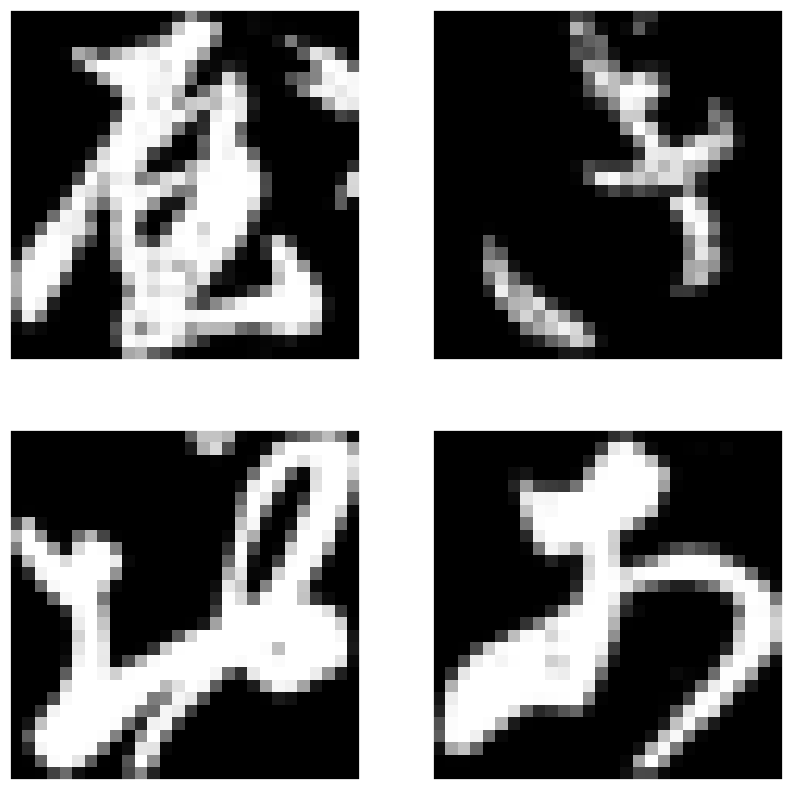

In [13]:
plot_grid(X_train)

## RandomOverSampler

In [11]:
class RandomOverSampler:
    def __init__(self, seed: int | None = None):
        self.seed = seed

    def _count_classes(self, y: np.ndarray) -> dict[int, int]:
        return { j: np.sum(y == i) for i, j in enumerate(np.unique(y)) }

    def fit_resample(self, X: np.ndarray, y: np.ndarray, target_count: int = -1) -> tuple[np.ndarray, np.ndarray]:
        rng = np.random.default_rng(self.seed)

        counts = self._count_classes(y)
        target_count = max(max(counts.values()), target_count or 0)

        sampled_X = []
        sampled_y = []

        for label, c in counts.items():
            needed = target_count - c
            label_idx = np.where(y == label)[0]
            sampled_idx = rng.choice(label_idx, size=needed, replace=True)
            sampled_X.append(X[sampled_idx])
            sampled_y.append(y[sampled_idx])

        resampled_X = np.concat([X] + sampled_X, axis=0)
        resampled_y = np.concat([y] + sampled_y, axis=0)

        idx = np.arange(resampled_y.shape[0])
        rng.shuffle(idx)
        print(idx)
        
        return resampled_X[idx], resampled_y[idx]


In [12]:
# create train and validation datasets, these datasets should use flattened images
ros = RandomOverSampler(42)

X_train_unb, X_test, y_train_unb, y_test = train_test_split(X, y, random_state=42)

X_train, y_train = ros.fit_resample(X_train_unb, y_train_unb)

[ 39085  40880 173886 ... 180744 200522 246129]


In [13]:
ros._count_classes(y_train)

{np.int64(0): np.int64(5336),
 np.int64(1): np.int64(5336),
 np.int64(2): np.int64(5336),
 np.int64(3): np.int64(5336),
 np.int64(4): np.int64(5336),
 np.int64(5): np.int64(5336),
 np.int64(6): np.int64(5336),
 np.int64(7): np.int64(5336),
 np.int64(8): np.int64(5336),
 np.int64(9): np.int64(5336),
 np.int64(10): np.int64(5336),
 np.int64(11): np.int64(5336),
 np.int64(12): np.int64(5336),
 np.int64(13): np.int64(5336),
 np.int64(14): np.int64(5336),
 np.int64(15): np.int64(5336),
 np.int64(16): np.int64(5336),
 np.int64(17): np.int64(5336),
 np.int64(18): np.int64(5336),
 np.int64(19): np.int64(5336),
 np.int64(20): np.int64(5336),
 np.int64(21): np.int64(5336),
 np.int64(22): np.int64(5336),
 np.int64(23): np.int64(5336),
 np.int64(24): np.int64(5336),
 np.int64(25): np.int64(5336),
 np.int64(26): np.int64(5336),
 np.int64(27): np.int64(5336),
 np.int64(28): np.int64(5336),
 np.int64(29): np.int64(5336),
 np.int64(30): np.int64(5336),
 np.int64(31): np.int64(5336),
 np.int64(32): np.

In [14]:
class BalancedAccuracy(keras.metrics.MeanMetricWrapper):
    def __init__(self, n_classes: int, *args, **kwargs):
        self.n_classes = n_classes
        super().__init__(fn=self.__call__, *args, **kwargs)
        # Metric should be maximized during optimization.
        self._direction = "up"

    # def __call__(self, y_true, y_pred):
    #     y_pred = tf.argmax(y_pred, axis=1)
    #     accs = []
    #     for cls in range(self.n_classes):
    #         mask = tf.equal(y_true, cls)
    #         masked = tf.boolean_mask(tf.equal(y_pred, cls), mask)
            
    #         cls_acc = tf.reduce_mean(tf.cast(masked, tf.float32))
            
    #         accs.append( tf.where(tf.math.is_nan(cls_acc), 0.0, cls_acc))
            
    #     return tf.reduce_mean(accs)
    
    def __call__(self, y_true, y_pred):
        y_pred_class = torch.argmax(y_pred, dim=1)   # predicted class indices
        accs = []
        
        for cls in range(self.n_classes):
            mask = (y_true == cls)                   # boolean mask for true class = cls
            if mask.any():
                correct = (y_pred_class[mask] == cls)  # correct predictions within this class
                cls_acc = correct.float().mean()       # recall for this class
            else:
                cls_acc = torch.tensor(0.0, device=y_true.device)  # no samples -> 0 contribution
            accs.append(cls_acc)
        
        return torch.stack(accs).mean()

    # def __call__(self, y_true, y_pred):
    #     y_pred = np.argmax(y_pred, axis=1)
    #     accs = []
    #     for cls in range(self.n_classes):
    #         mask = y_true == cls
    #         cls_acc = (y_pred == cls)[mask].mean()
            
    #         accs.append( cls_acc )
            
    #     return accs.mean()
        
    def get_config(self):
        return {"name": self.name, "dtype": self.dtype}

In [15]:
balanced_accuracy = BalancedAccuracy(N_CLASSES)

## Flattened images
Use Dense layers

In [110]:
# create model, this model should accept a flattened image
x = inputs = keras.layers.Input((28*28,))
x = keras.layers.Dense(1024, name="dense_1")(x)
x = keras.layers.BatchNormalization(name="b_norm")(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.Dropout(0.3, name="drop")(x)
x = keras.layers.Dense(128, activation='relu', name="dense_2")(x)
x = keras.layers.Dense(N_CLASSES, activation='softmax', name="dense_softmax")(x)

model = keras.models.Model(inputs, x)

In [111]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b_norm (BatchNormalization)     │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_softmax (Dense)           │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 945,457 (3.61 MB)

 Trainable params: 943,409 (3.60 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [112]:
logdir = pathlib.Path('logs/kuzushiji-49') / datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
logdir.mkdir(parents=True, exist_ok=True)
logdir

WindowsPath('logs/kuzushiji-49/20260513-234205')

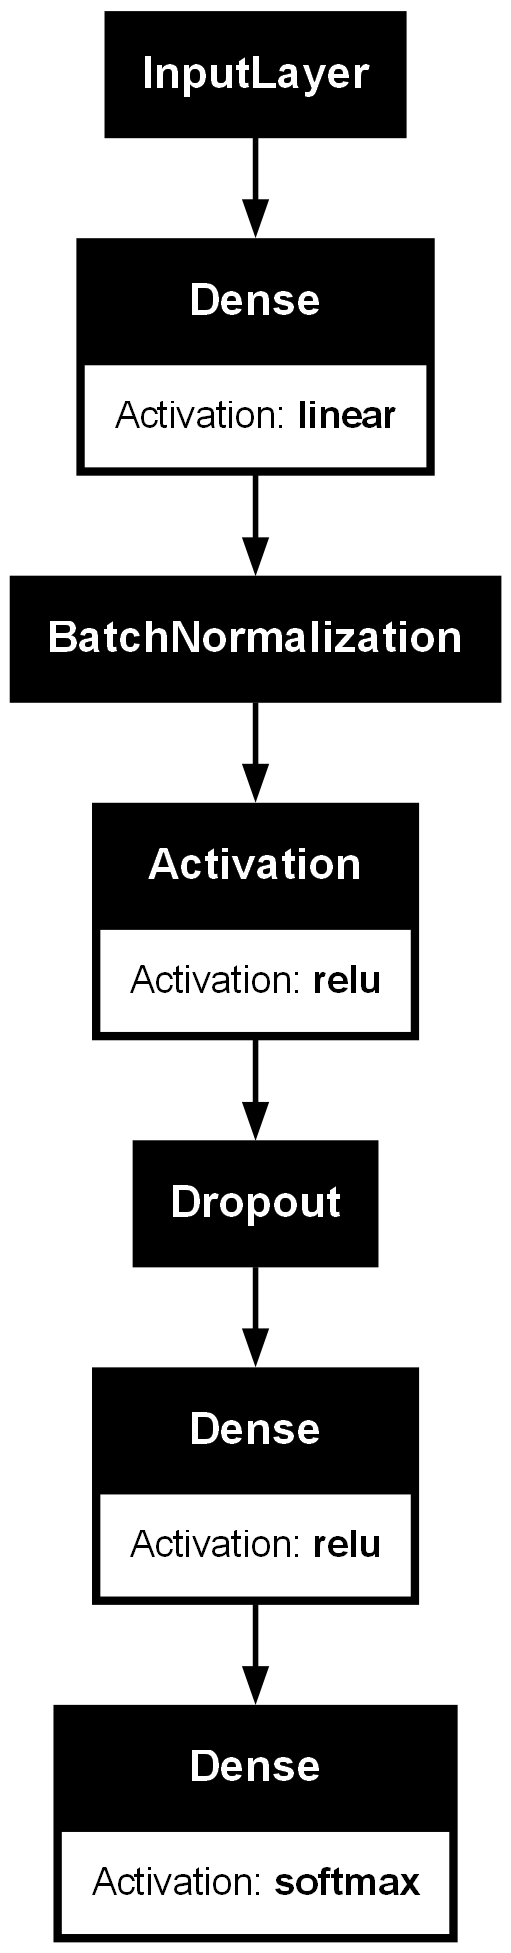

In [113]:
keras.utils.plot_model(model, to_file=logdir / "model_flat.png", show_layer_activations=True)

In [114]:
callbacks = [
    keras.callbacks.ModelCheckpoint(logdir / "model_flat.keras", save_best_only=True, monitor='val_loss'),
    keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [115]:
# compile the model, make sure to add accuracy metric
model.compile(
    'nadam', 
    loss=keras.losses.SparseCategoricalCrossentropy(), 
    metrics=[
        balanced_accuracy,
    ],
)

In [116]:
# model.load_weights("logs/kuzushiji-49/20260509-200755/model_flat_hand_saved.keras")

In [ ]:
# model.save( logdir / "model_flat_hand_saved.keras")

In [118]:
# train the model, make sure to use callbacks and validation dataset
model.fit(
    X_train, y_train, 
    batch_size=512, 
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - balanced_accuracy_2: 0.7688 - loss: 0.8963 - val_balanced_accuracy_2: 0.8334 - val_loss: 0.5617
Epoch 2/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - balanced_accuracy_2: 0.8672 - loss: 0.4961 - val_balanced_accuracy_2: 0.8575 - val_loss: 0.4610
Epoch 3/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - balanced_accuracy_2: 0.8921 - loss: 0.3950 - val_balanced_accuracy_2: 0.8697 - val_loss: 0.4069
Epoch 4/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - balanced_accuracy_2: 0.9075 - loss: 0.3337 - val_balanced_accuracy_2: 0.8810 - val_loss: 0.3764
Epoch 5/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 49s 95ms/step - balanced_accuracy_2: 0.9184 - loss: 0.2923 - val_balanced_accuracy_2: 0.8841 - val_loss: 0.3519
Epoch 6/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 64s 126ms/step - balanced_accuracy_2: 0.9269 - loss: 0.2592 - val_balanced_accuracy_2: 0.8883 - val_loss: 0.3405
Epoch 7/10
511/511 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - balanced_accuracy_2: 0.9335 - l

In [119]:
model.evaluate(X_test, y_test, batch_size=512)

133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - balanced_accuracy_2: 0.8968 - loss: 0.3123


[0.3123134970664978, 0.8968468308448792]

In [120]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


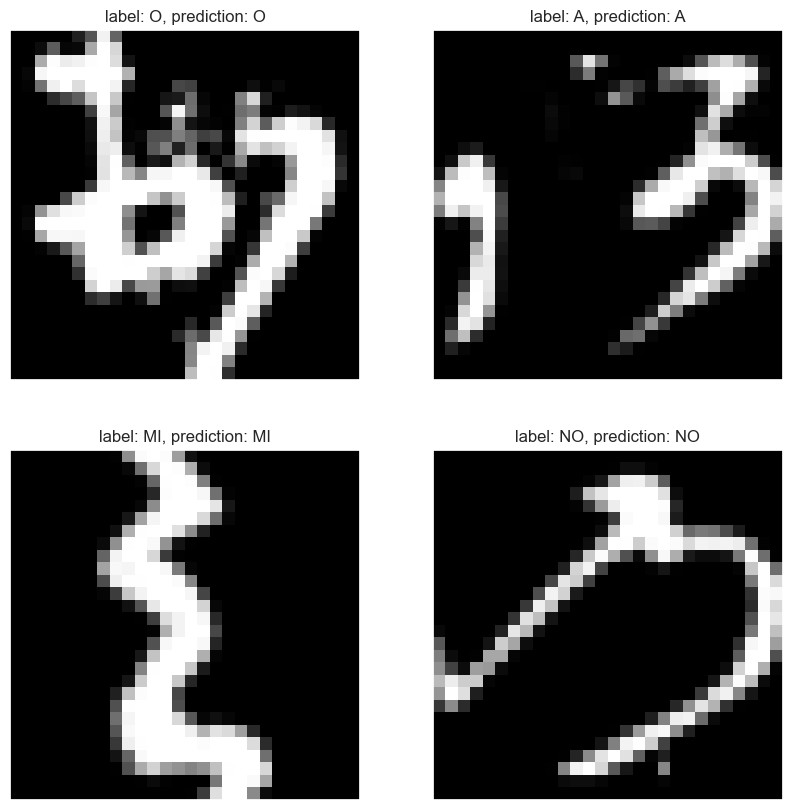

In [122]:
plot_grid_and_label(images, y_test, model, label_description=label_description)

In [124]:
y_pred = model.predict(X_test, batch_size=512)

  1/133 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [125]:
y_pred = np.argmax(y_pred, axis=1)

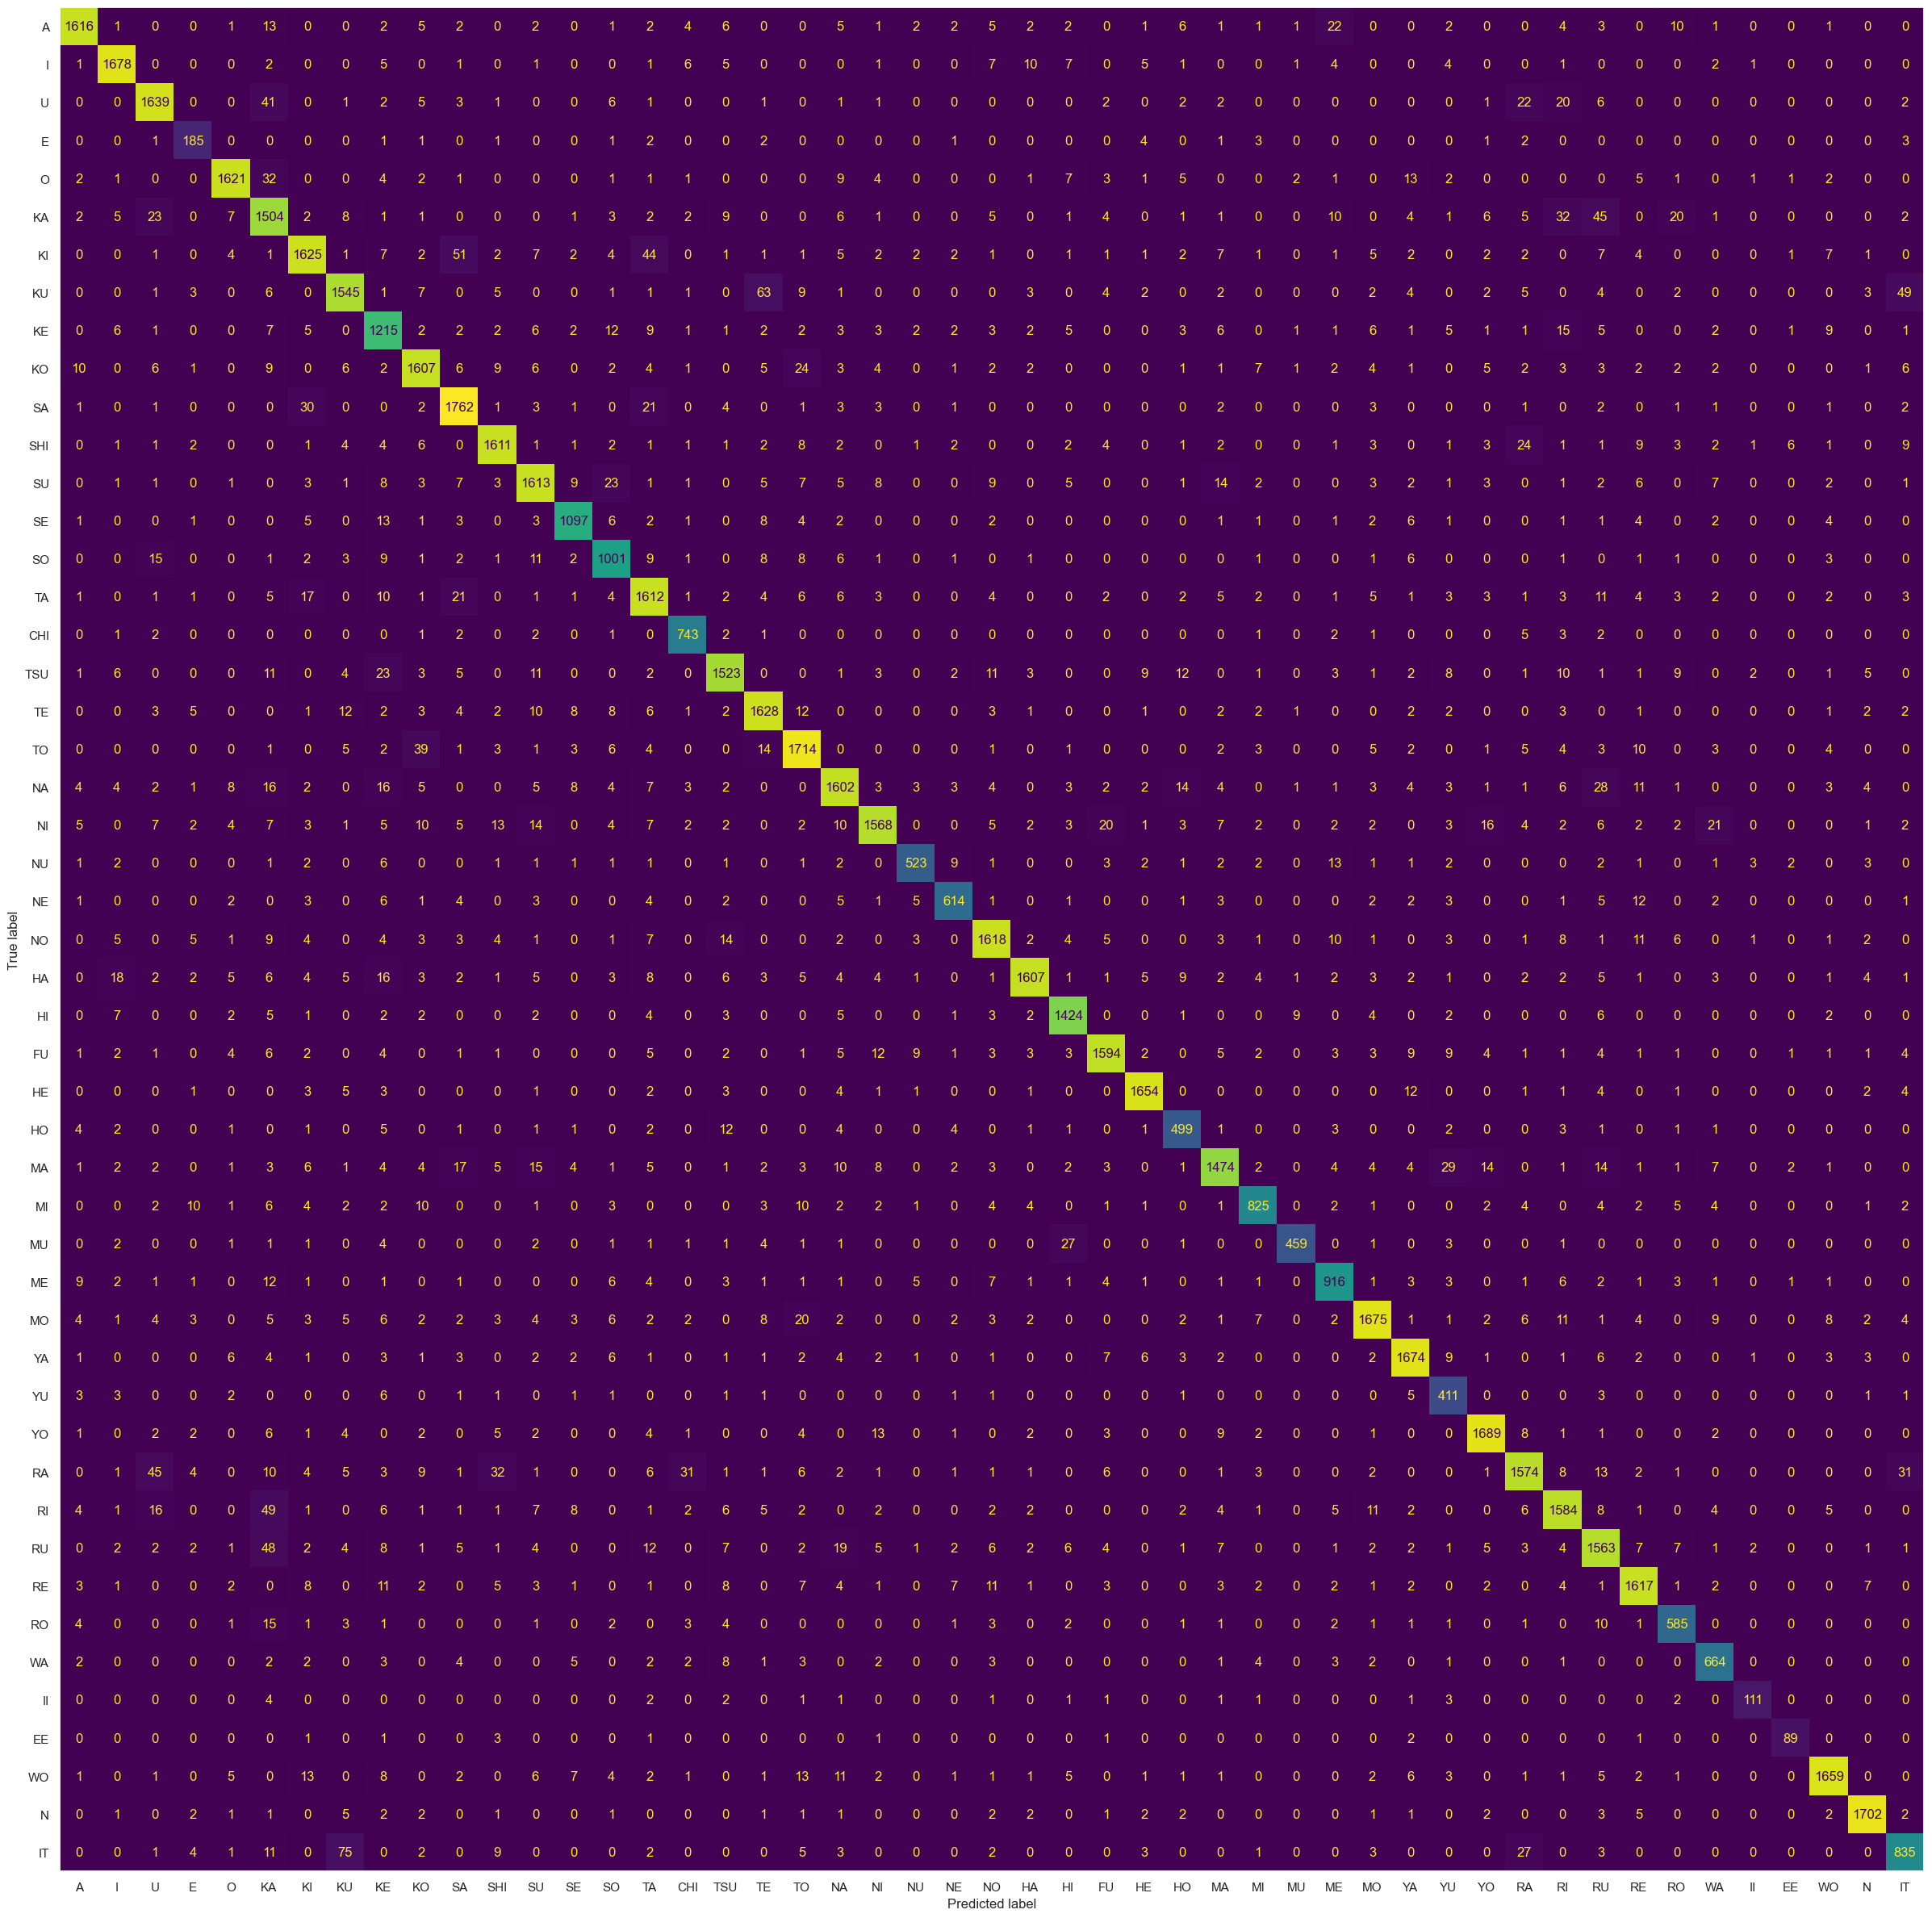

In [126]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [129]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.916005614766913)

## Actual images
Use Conv2D layers with Dense layer on top

In [16]:
# create train and validation datasets, these datasets should use 28x28x1 images
X_train2 = X_train.reshape(-1, 28, 28, 1)
X_test2 = X_test.reshape(-1, 28, 28, 1)
X_train2.shape, X_test2.shape

((261464, 28, 28, 1), (67728, 28, 28, 1))

In [17]:
def res_block(inp, dim: int, name: str | None = None, is_first: bool=False):
    x = inp

    x = keras.layers.Conv2D(dim, 3, strides=1 + is_first, activation='relu', padding='same', name=f"{name}_conv_1")(x)
    x = keras.layers.Conv2D(dim, 3, padding='same', name=f"{name}_conv_2")(x)
    if (not is_first):
        x = keras.layers.Add(name=f"{name}_add")([x, inp])

    return x

def res_block2(inp, dim: int, name: str | None = None, is_first: bool=False):
    x = inp

    x = keras.layers.Conv2D(dim // 4, 1, strides=1 + is_first, activation='relu', padding='same', name=f"{name}_conv_1")(x)
    x = keras.layers.Conv2D(dim // 4, 3, padding='same', name=f"{name}_conv_2")(x)
    x = keras.layers.Conv2D(dim, 1, name=f"{name}_conv_3")(x)
    if (not is_first):
        x = keras.layers.Add(name=f"{name}_add")([x, inp])

    return x

In [18]:
# create model, this model should accept a 28x28x1 image

x = inputs = keras.layers.Input((28, 28, 1), name='inp')

x = keras.layers.Conv2D(64, 3, strides=1, padding='same', name="inp_conv")(x)
x = keras.layers.AvgPool2D(3, strides=1, padding='same', name="inp_avg")(x)

x = res_block2(x, 64, name="rb_1_1")
x = res_block2(x, 64, name="rb_1_2")

x = res_block2(x, 128, is_first=True, name="rb_2_1")
x = res_block2(x, 128, name="rb_2_2")

x = res_block2(x, 256, is_first=True, name="rb_3_1")
x = res_block2(x, 256, name="rb_3_2")

x = keras.layers.AveragePooling2D(3, 2, name="ad_avg_pool_end")(x)
x = keras.layers.Flatten(name="flatten")(x)
# x = keras.layers.Dense(1000, activation='relu', name="dense_1000")(x)
x = keras.layers.Dense(N_CLASSES, activation='softmax', name="dense_softmax")(x)

model2 = keras.models.Model(inputs, x)

In [19]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inp (InputLayer)    │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inp_conv (Conv2D)   │ (None, 28, 28,    │        640 │ inp[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inp_avg             │ (None, 28, 28,    │          0 │ inp_conv[0][0]    │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_1_conv_1       │ (None, 28, 28,    │      1,040 │ inp_avg[0][0]     │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_1_conv_2       │ (None, 28, 28,    │      2,320 │ rb_1_1_conv_1[0]… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_1_conv_3       │ (None, 28, 28,    │      1,088 │ rb_1_1_conv_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_1_add (Add)    │ (None, 28, 28,    │          0 │ rb_1_1_conv_3[0]… │
│                     │ 64)               │            │ inp_avg[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_2_conv_1       │ (None, 28, 28,    │      1,040 │ rb_1_1_add[0][0]  │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_2_conv_2       │ (None, 28, 28,    │      2,320 │ rb_1_2_conv_1[0]… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_2_conv_3       │ (None, 28, 28,    │      1,088 │ rb_1_2_conv_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_1_2_add (Add)    │ (None, 28, 28,    │          0 │ rb_1_2_conv_3[0]… │
│                     │ 64)               │            │ rb_1_1_add[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_2_1_conv_1       │ (None, 14, 14,    │      2,080 │ rb_1_2_add[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_2_1_conv_2       │ (None, 14, 14,    │      9,248 │ rb_2_1_conv_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_2_1_conv_3       │ (None, 14, 14,    │      4,224 │ rb_2_1_conv_2[0]… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_2_2_conv_1       │ (None, 14, 14,    │      4,128 │ rb_2_1_conv_3[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_2_2_conv_2       │ (None, 14, 14,    │      9,248 │ rb_2_2_conv_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rb_2_2_conv_3       │ (None, 14, 14,    │      4,224 │ rb_2_2_conv_2[0]… │
│ (Conv2D)            │ 128)              │            │                 

 Total params: 287,473 (1.10 MB)

 Trainable params: 287,473 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
logdir = pathlib.Path('logs/kuzushiji-49') / datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
logdir.mkdir(parents=True, exist_ok=True)
logdir

WindowsPath('logs/kuzushiji-49/20260514-000212')

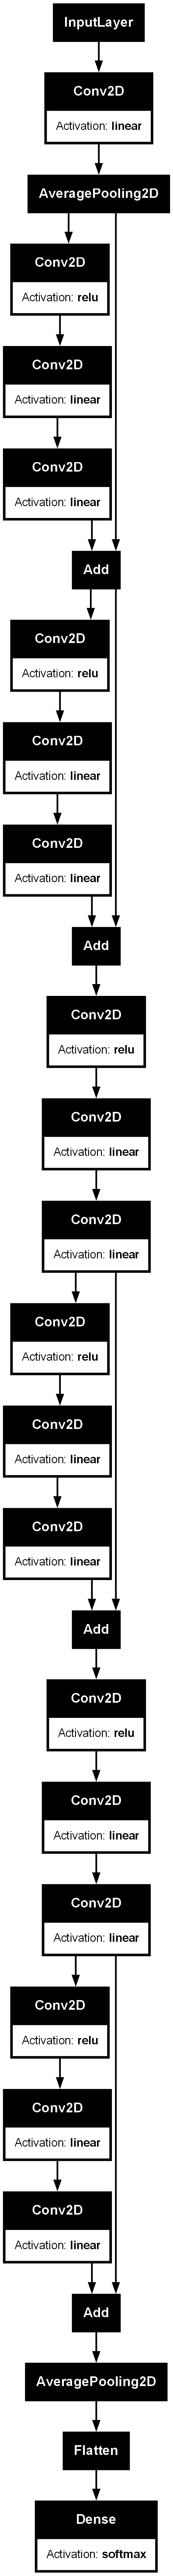

In [23]:
keras.utils.plot_model(model2, to_file=logdir / "model_2d.png", show_layer_activations=True)

In [25]:
callbacks = [
    keras.callbacks.ModelCheckpoint(logdir / "model_2d.keras", save_best_only=True, monitor='val_loss'),
    keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [26]:
# compile the model, make sure to add accuracy metric
model2.compile(
    'nadam', 
    loss=keras.losses.SparseCategoricalCrossentropy(), 
    metrics=[
        balanced_accuracy,
    ],
)

In [ ]:
# model2.load_weights("logs/kuzushiji-49/20260509-215533/model_2d_hand_saved.keras")

In [ ]:
# model2.save(logdir / "model_2d_hand_saved.keras")

In [27]:
# train the model, make sure to use callbacks and validation dataset
model2.fit(
    X_train2, y_train, 
    batch_size=128, 
    epochs=10,
    validation_data=(X_test2, y_test),
    callbacks=callbacks,
)

Epoch 1/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 127s 62ms/step - balanced_accuracy: 0.8094 - loss: 0.4917 - val_balanced_accuracy: 0.7856 - val_loss: 0.3182
Epoch 2/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 123s 60ms/step - balanced_accuracy: 0.8690 - loss: 0.2274 - val_balanced_accuracy: 0.8055 - val_loss: 0.2429
Epoch 3/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 122s 60ms/step - balanced_accuracy: 0.8765 - loss: 0.1959 - val_balanced_accuracy: 0.8079 - val_loss: 0.2314
Epoch 4/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 123s 60ms/step - balanced_accuracy: 0.8820 - loss: 0.1752 - val_balanced_accuracy: 0.8061 - val_loss: 0.2325
Epoch 5/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 123s 60ms/step - balanced_accuracy: 0.8851 - loss: 0.1611 - val_balanced_accuracy: 0.8140 - val_loss: 0.1981
Epoch 6/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 125s 61ms/step - balanced_accuracy: 0.8893 - loss: 0.1491 - val_balanced_accuracy: 0.8152 - val_loss: 0.1978
Epoch 7/10
2043/2043 ━━━━━━━━━━━━━━━━━━━━ 124s 61ms/step - balanced_accuracy: 0.8911 - loss: 0

In [29]:
images = X_test2.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


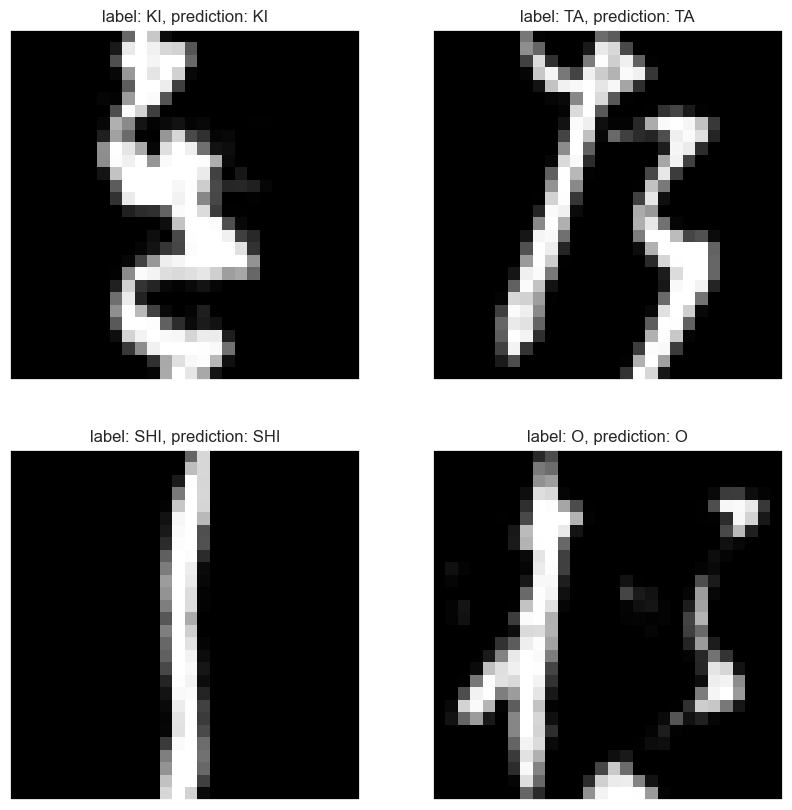

In [34]:
plot_grid_and_label(images, y_test, model2, label_description=label_description, flatten_image=False)

In [32]:
y_pred = model2.predict(X_test2, batch_size=128)

530/530 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step


In [35]:
y_pred = np.argmax(y_pred, axis=1)

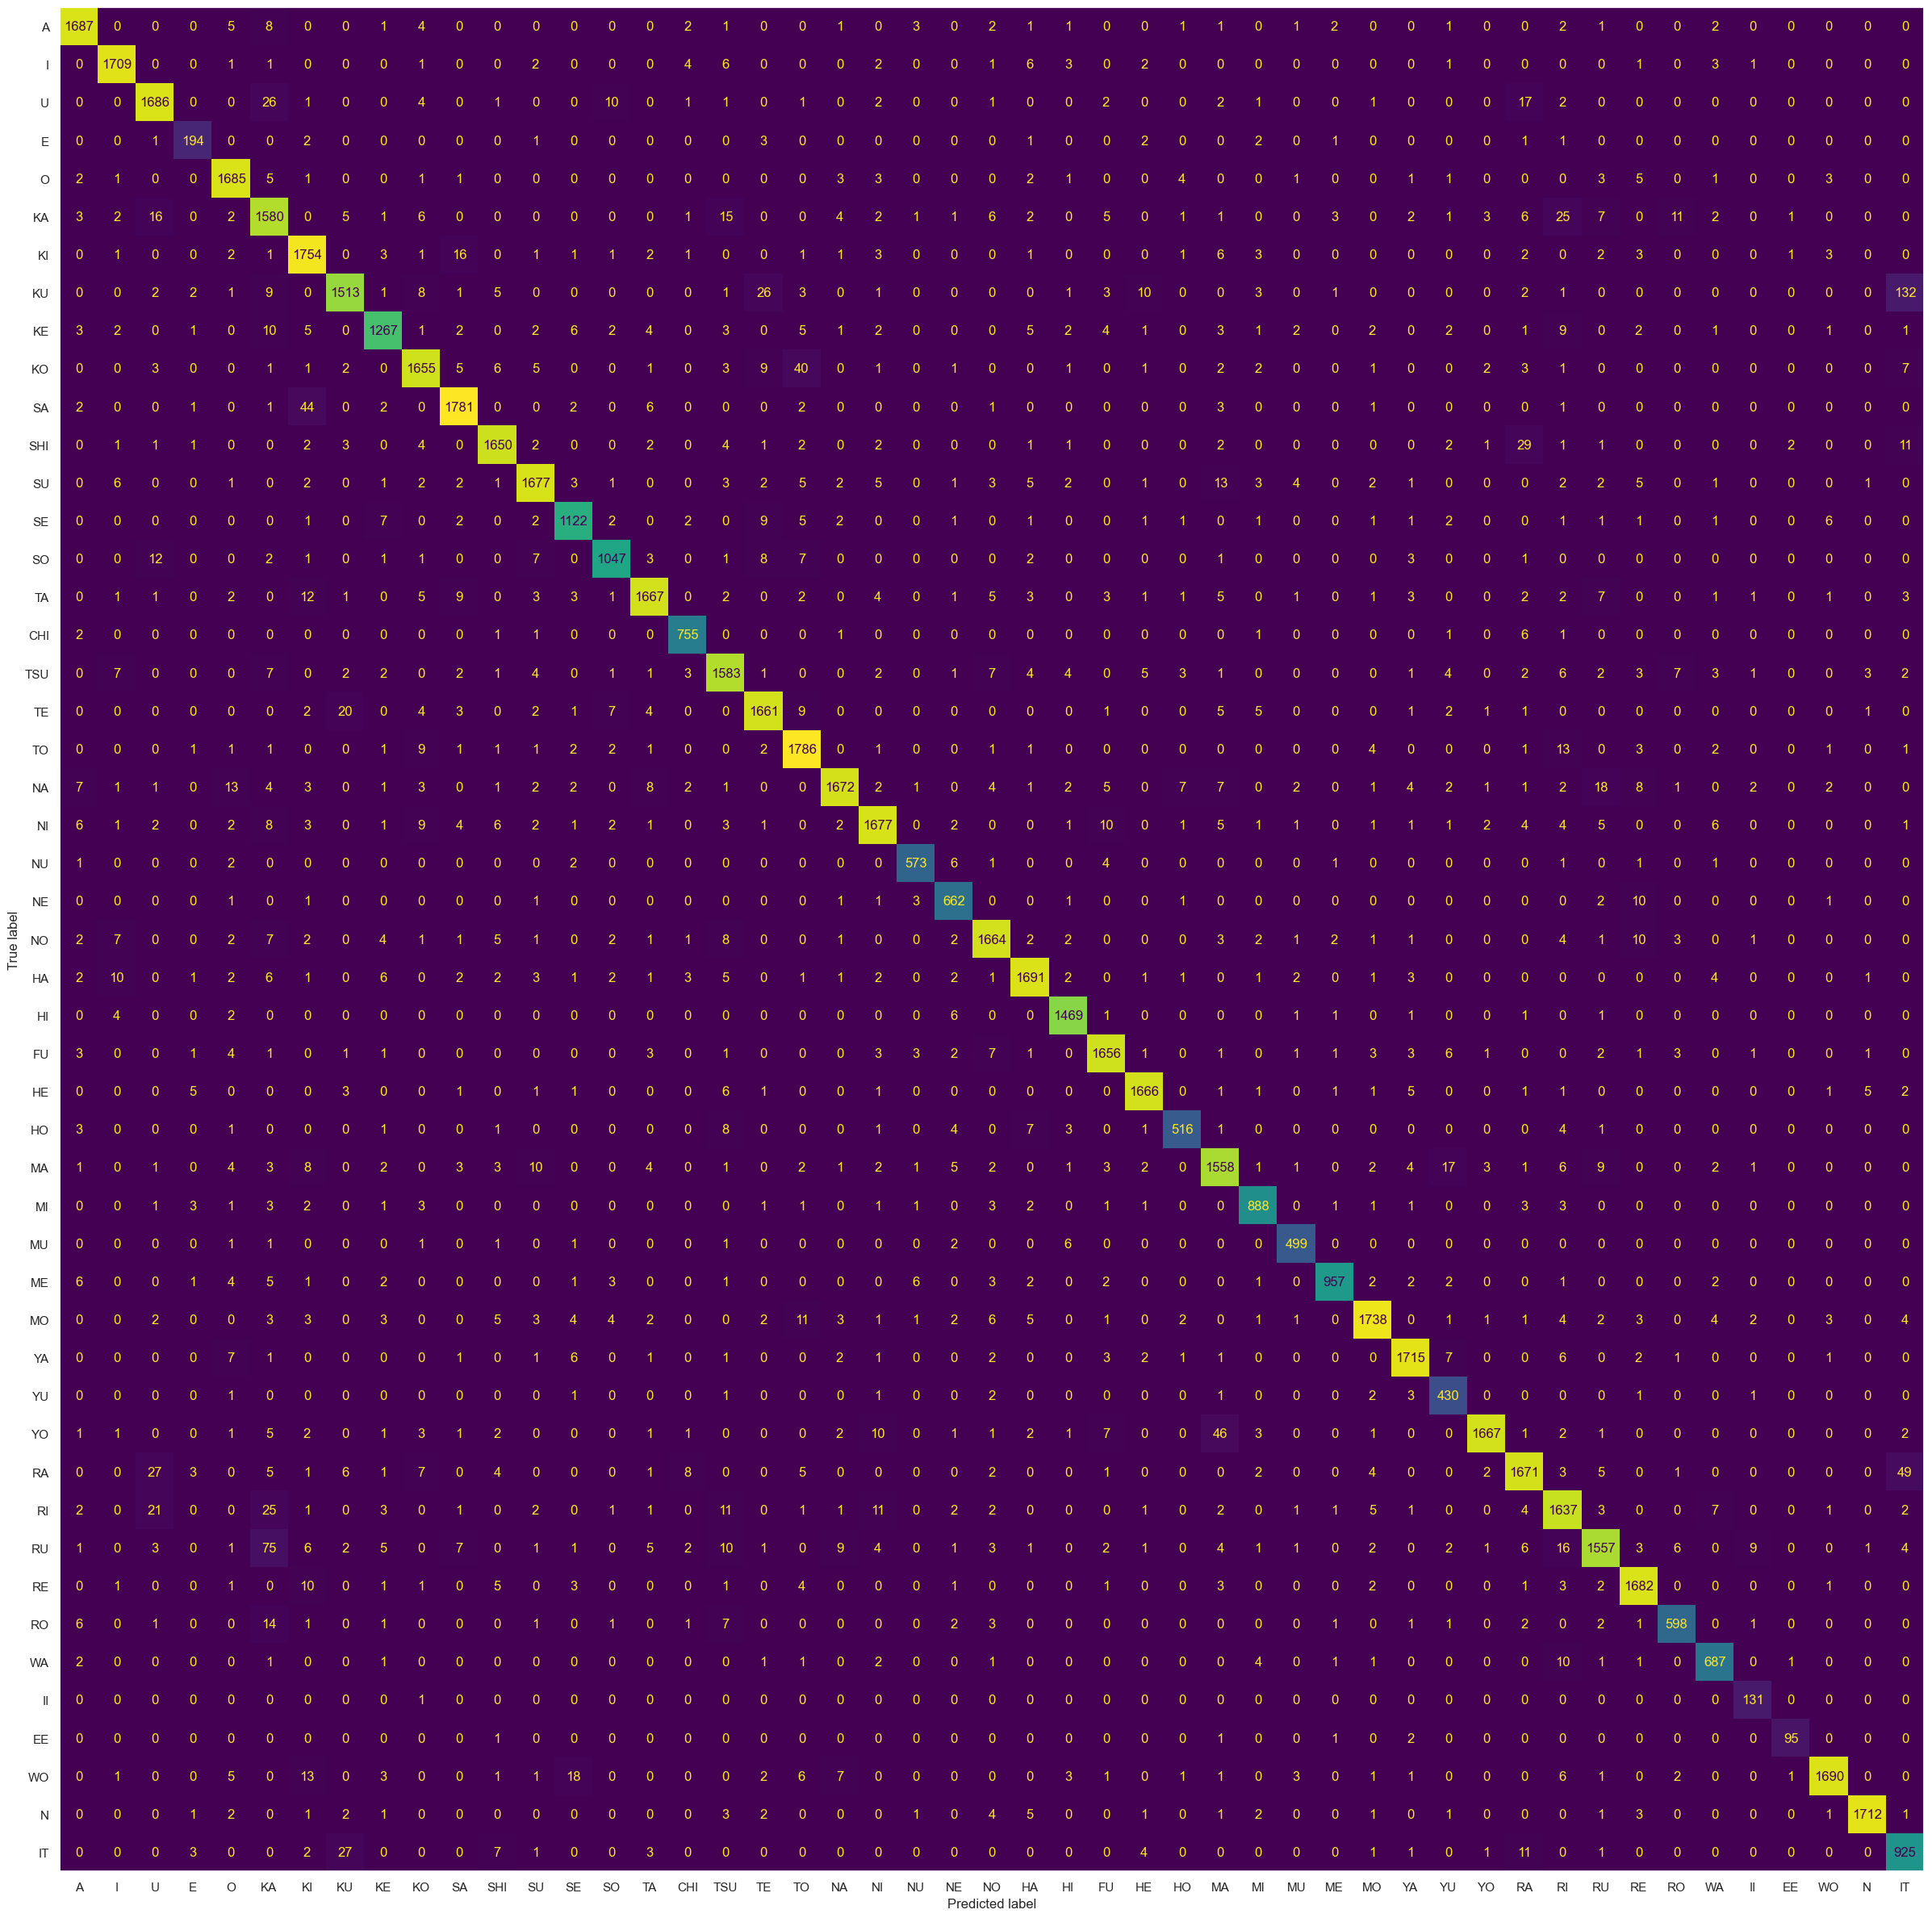

In [36]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [37]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9539144187007381)